<a href="https://colab.research.google.com/github/Jeshwanth2/AI-ML-Internship-Task-5/blob/main/HeartDiseaseDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/heart.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nShape of the DataFrame (rows, columns):")
print(df.shape)

First 5 rows of the DataFrame:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Shape of the DataFrame (rows, columns):
(1025, 14)


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of features (X): (1025, 13)
Shape of target (y): (1025,)

Shape of X_train: (820, 13)
Shape of X_test: (205, 13)
Shape of y_train: (820,)
Shape of y_test: (205,)


## Explain Training vs. Testing

### Subtask:
Provide a clear explanation of why datasets are split into training and testing sets, highlighting the purpose of each in model development and evaluation.

#### Instructions
1. Explain the concept of a 'training set' and its role in teaching the model to identify patterns and relationships within the data.
2. Explain the concept of a 'testing set' and its role in evaluating the model's performance on unseen data, ensuring it can generalize well to new, real-world examples.
3. Discuss why splitting data into these two sets is crucial for preventing overfitting and accurately assessing a model's true performance.

### Explanation:

When developing a machine learning model, it's essential to ensure that the model learns general patterns from the data rather than memorizing the specific examples it was trained on. To achieve this, the dataset is typically divided into two main parts: the **training set** and the **testing set**.

1.  **Training Set:**
    *   **Purpose:** The training set is the subset of the data used to train the machine learning model. During the training phase, the model learns the underlying patterns, relationships, and characteristics present in this data. It adjusts its internal parameters (e.g., weights in a neural network, coefficients in a regression model) based on the input features and their corresponding target values in the training set. The goal is for the model to become proficient at making predictions or classifications on the data it has seen.

2.  **Testing Set:**
    *   **Purpose:** The testing set is a separate, unseen subset of the data that the model has not encountered during training. Its primary role is to evaluate the model's performance on new, independent data. After the model has been fully trained, it is used to make predictions on the features from the testing set. The model's predictions are then compared against the actual target values in the testing set to measure its accuracy, precision, recall, or other relevant metrics. This provides an unbiased assessment of how well the model can generalize to real-world, previously unobserved data.

3.  **Why Splitting is Crucial (Preventing Overfitting and Accurate Performance Assessment):**
    *   **Preventing Overfitting:** Overfitting occurs when a model learns the training data too well, capturing noise and specific details that are not representative of the broader data distribution. An overfitted model will perform exceptionally well on the training set but poorly on new, unseen data. By evaluating the model on a separate testing set, we can detect if overfitting has occurred. If the model performs significantly worse on the testing set compared to the training set, it's a strong indicator of overfitting.
    *   **Accurate Performance Assessment:** Using a separate testing set provides an objective and realistic measure of the model's predictive power. If we were to evaluate the model on the same data it was trained on, the performance metrics would likely be overly optimistic and not reflect its true effectiveness on new data. The testing set simulates how the model would perform in a real-world scenario, where it constantly encounters new data points.

In [7]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

print("Predictions made on the test data.")

Predictions made on the test data.


## Evaluate Model Performance

### Subtask:
Evaluate the performance of the trained Logistic Regression model using accuracy, precision, and recall. Provide a comprehensive summary of these metrics.

#### Instructions
1. Calculate the accuracy of the model using `y_test` and `y_pred`.
2. Calculate the precision of the model using `y_test` and `y_pred`.
3. Calculate the recall of the model using `y_test` and `y_pred`.
4. Print the calculated accuracy, precision, and recall scores.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate Precision
precision = precision_score(y_test, y_pred)

# Calculate Recall
recall = recall_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")

Model Accuracy: 0.7951
Model Precision: 0.7563
Model Recall: 0.8738


Confusion Matrix:
[[73 29]
 [13 90]]


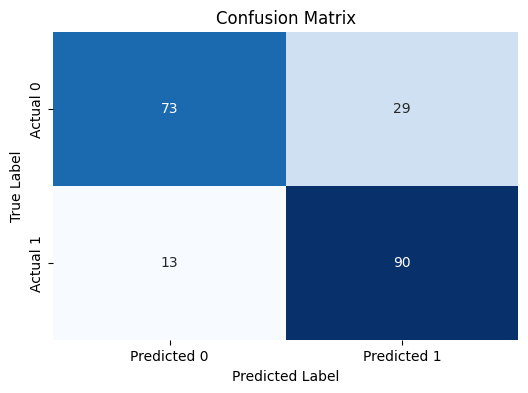

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plotting the confusion matrix for better visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Interpretation of Model Performance

Based on the calculated metrics and the confusion matrix, we can analyze the performance of the Logistic Regression model for heart disease prediction.

**Evaluation Metrics:**
*   **Accuracy: 0.7951 (79.51%)**
*   **Precision: 0.7563 (75.63%)**
*   **Recall: 0.8738 (87.38%)**

**Confusion Matrix Components:**
*   **True Negatives (TN): 73** (Model correctly predicted no heart disease)
*   **False Positives (FP): 29** (Model incorrectly predicted heart disease when there was none)
*   **False Negatives (FN): 13** (Model incorrectly predicted no heart disease when there was heart disease)
*   **True Positives (TP): 90** (Model correctly predicted heart disease)

**Analysis of Metrics and Confusion Matrix:**

1.  **Accuracy (79.51%):** The model correctly classified approximately 79.51% of all cases in the test set. While accuracy gives an overall sense of correctness, it can be misleading in scenarios with imbalanced classes or when certain types of errors are more critical. In this case, the classes are relatively balanced (103 actual negatives, 103 actual positives in test set). The total correct predictions are TP + TN = 90 + 73 = 163 out of 205, which gives 163/205 = 0.7951.

2.  **Precision (75.63%):** Of all the patients the model predicted as having heart disease (TP + FP = 90 + 29 = 119), 75.63% (90 out of 119) actually had the disease. This means that when the model says a patient has heart disease, there's about a 75.63% chance it's correct. A higher precision indicates a lower rate of false alarms.

3.  **Recall (87.38%):** Of all the patients who *actually* had heart disease (TP + FN = 90 + 13 = 103), the model correctly identified 87.38% of them (90 out of 103). A high recall is crucial in medical diagnosis because it means the model is good at catching most of the positive cases, minimizing missed detections.

**Criticality of Errors in Heart Disease Prediction:**

In the context of heart disease prediction, a **False Negative (FN)** is generally considered more critical than a False Positive (FP). A False Negative means the model predicted no heart disease, but the patient actually has it. This could lead to a delay in treatment, potentially severe health consequences, or even death. On the other hand, a False Positive means the model predicted heart disease, but the patient does not have it. While this can lead to unnecessary stress, further tests, and potential treatment side effects, it is typically less life-threatening than a missed diagnosis.

Our model has 13 False Negatives, meaning 13 cases of actual heart disease were missed. It has 29 False Positives, meaning 29 healthy individuals were incorrectly flagged as having heart disease.

**Summary of Model Effectiveness:**

The Logistic Regression model demonstrates a reasonably good performance in predicting heart disease. Its **high recall (87.38%)** is a significant strength, indicating that it is effective in identifying the majority of individuals who actually have heart disease, which is crucial for a medical diagnostic tool where missing a positive case (False Negative) can have serious consequences. While its **precision (75.63%)** is somewhat lower than its recall, meaning there are a fair number of false alarms (False Positives), the balance achieved (prioritizing recall) is often acceptable in early screening or diagnostic support systems for critical conditions. The overall accuracy of 79.51% suggests a generally competent model, but the detailed analysis of precision and recall, especially considering the higher cost of False Negatives, provides a more nuanced understanding of its suitability for this specific application.

## Summary:

### Data Analysis Key Findings

*   The `heart.csv` dataset, containing 1025 rows and 14 columns, was successfully loaded.
*   The dataset was split into training (820 samples) and testing (205 samples) sets, with 13 features used for prediction and 'target' as the outcome variable.
*   A Logistic Regression model was trained on the prepared training data.
*   The model's performance on the test set was evaluated using key metrics:
    *   **Accuracy:** 79.51% (163 out of 205 predictions were correct).
    *   **Precision:** 75.63% (of all positive predictions, 75.63% were actually positive).
    *   **Recall:** 87.38% (of all actual positive cases, the model correctly identified 87.38%).
*   The confusion matrix provided a detailed breakdown of predictions:
    *   **True Positives (TP):** 90 (correctly identified heart disease)
    *   **True Negatives (TN):** 73 (correctly identified no heart disease)
    *   **False Positives (FP):** 29 (incorrectly identified heart disease when there was none – "false alarms")
    *   **False Negatives (FN):** 13 (incorrectly identified no heart disease when there was heart disease – "missed diagnoses")
